In [3]:
import torch
import torchvision
from torch import nn
from torch.utils.data import dataloader
from torchvision import transforms

In [4]:
train_data=torchvision.datasets.FashionMNIST(root="data",train=True,download=True,transform=torchvision.transforms.ToTensor())

In [5]:
test_data=torchvision.datasets.FashionMNIST(root="data",train=False,download=True,transform=torchvision.transforms.ToTensor())

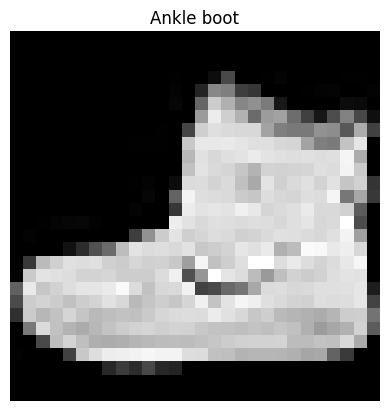

In [6]:
import matplotlib.pyplot as plt
img,label=train_data[0]
classes=train_data.classes
plt.imshow(img.squeeze(),cmap="grey")
plt.title(classes[label])
plt.axis("off")
plt.show()

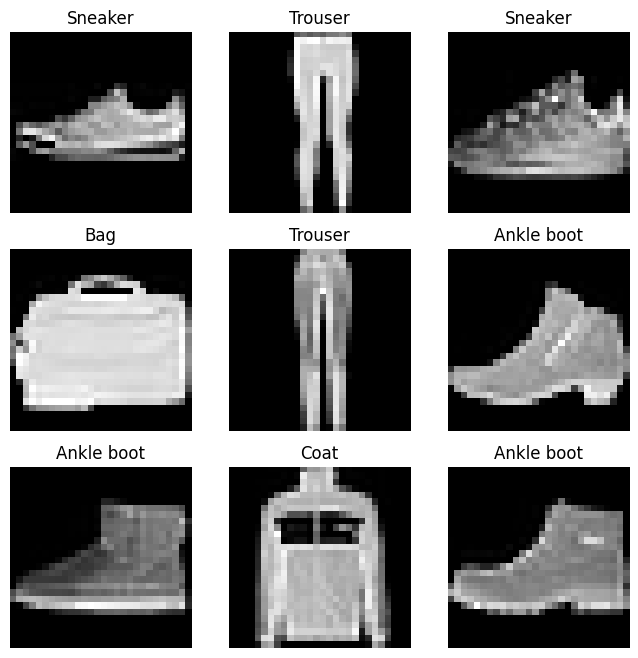

In [10]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flat:
    idx = random.randint(0, len(train_data) - 1)

    image, label = train_data[idx]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(train_data.classes[label])
    ax.axis("off")

plt.show()

In [32]:
class Model(nn.Module):
    def __init__(self,input,hidden,output):
        super().__init__()
        self.conv_layer=nn.Sequential(
            nn.Conv2d(in_channels=input,out_channels=hidden,kernel_size=3,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,out_channels=hidden,kernel_size=3,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.linear_layer=nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(out_features=output)
        )
    def forward(self,x):
        x=self.conv_layer(x)
        x=self.linear_layer(x)
        return x
model=Model(1,32,len(train_data.classes))

In [37]:
from torch.utils.data import DataLoader
dataload_train=DataLoader(train_data,32,shuffle=True)
dataload_test=DataLoader(test_data,32,shuffle=True)
len(dataload_train)

1875

In [34]:
loss_fn=nn.CrossEntropyLoss()

In [35]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [36]:
epochs=3
for epoch in range(epochs):
    train_loss=0
    train_acc=0
    model.train()
    for X,y in dataload_train:
        y_logit=model(X)
        loss=loss_fn(y_logit,y)
        y_pred=torch.argmax(y_logit,dim=1)
        train_loss+=loss.item()
        correct=(y_pred==y).sum().item()
        batch_acc=correct/len(y)
        train_acc+=batch_acc
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss/=len(dataload_train)
    train_acc/=len(dataload_train)
    print(f"epoch:{epoch+1},loss:{loss.item()},Acc:{train_acc}")


epoch:1,loss:0.552941620349884,Acc:0.80485
epoch:2,loss:0.3547959327697754,Acc:0.8369833333333333
epoch:3,loss:0.2888740599155426,Acc:0.8503333333333334


In [40]:
test_loss=0
correct=0
total=0
with torch.inference_mode():
    for X,y in dataload_test:
        y_logit=model(X)
        loss=loss_fn(y_logit,y)
        y_pred=torch.argmax(y_logit,dim=1)
        correct+=(y_pred==y).sum().item()
        test_loss+=loss.item()
        total+=len(y)
test_acc=correct/total
test_loss=test_loss/len(dataload_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Test Loss: 0.4410
Test Acc : 0.8458


In [41]:
from sklearn.metrics import classification_report

model.eval()

y_true = []
y_preds = []

with torch.inference_mode():

    for X, y in dataload_test:

        y_logit = model(X)

        y_pred = torch.argmax(y_logit, dim=1)

        y_true.extend(y.numpy())
        y_preds.extend(y_pred.numpy())

print(
    classification_report(
        y_true,
        y_preds,
        target_names=train_data.classes
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.82      0.80      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.69      0.81      0.74      1000
       Dress       0.86      0.85      0.86      1000
        Coat       0.78      0.67      0.72      1000
      Sandal       0.95      0.96      0.95      1000
       Shirt       0.63      0.59      0.61      1000
     Sneaker       0.95      0.90      0.92      1000
         Bag       0.93      0.95      0.94      1000
  Ankle boot       0.91      0.97      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_preds)

print(cm)

[[819   1  22  43   7   2  86   0  20   0]
 [  3 949   2  35   5   0   2   0   4   0]
 [ 26   0 805   6  60   0  96   0   7   0]
 [ 34   5  33 850  31   0  44   1   2   0]
 [  2   0 189  28 673   0 105   0   3   0]
 [  0   0   0   0   0 959   1  22   1  17]
 [164   0 104  22  81   0 591   0  38   0]
 [  0   0   0   0   0  30   0 899   0  71]
 [  4   1   8   4   3  14  13   4 946   3]
 [  0   0   0   0   0   8   0  24   1 967]]


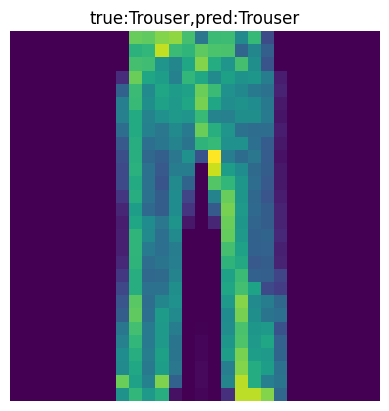

In [53]:
import matplotlib.pyplot as plt
X,y=next(iter(dataload_test))
with torch.inference_mode():
    y_logit=model(X)
    y_pred=torch.argmax(y_logit,dim=1)
plt.imshow(X[0].squeeze())
plt.title(f"true:{train_data.classes[y[0]]},pred:{train_data.classes[y_pred[0]]}")
plt.axis("off")
plt.show()

In [55]:
import os
folder="models"
model_path=os.path.join(folder,"convolution.pth")

In [56]:
torch.save(model.state_dict(),model_path)